## snake cnn project

In [1]:
import tensorflow as tf
from tensorflow import keras
import os
from keras import utils, datasets, layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import warnings

2024-12-03 13:34:13.830420: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
warnings.filterwarnings("ignore") 

In [3]:
gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
import cv2
import imghdr

## Gather image paths

In [7]:
data_dir = "root/Snakes_CLEAN"
image_exts = ["jpeg", "jpg", "bpm", "png"]

In [8]:
os.listdir(os.path.join(data_dir))

['.DS_Store',
 'coral_snake',
 'rattlesnake',
 'ribbon_snake',
 'yellow_eyelash_viper',
 'boa']

In [9]:
listdir = os.listdir(os.path.join(data_dir))
listdir = listdir[1:] 
listdir

['coral_snake', 'rattlesnake', 'ribbon_snake', 'yellow_eyelash_viper', 'boa']

In [10]:
for image_class in listdir:
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print("Image not in ext list {}".format(image_path))
                os.remove(image_path)
        except Exception as e:
            print("Issue with image {}".format(image_path))
            #os.remove(image_path)

In [ ]:
# Display image from numpy array
img = cv2.imread(os.path.join(data_dir, "coluber_constrictor", "322.jpeg"))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

### Load Data

In [12]:
data = tf.keras.utils.image_dataset_from_directory(data_dir, batch_size = 64)

Found 2430 files belonging to 5 classes.


In [13]:
data_iterator = data.as_numpy_iterator()
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x1495f09b0>)

In [13]:
tf.autograph.set_verbosity(
    level=0, alsologtostdout=False
)

In [14]:
batch = data_iterator.next()

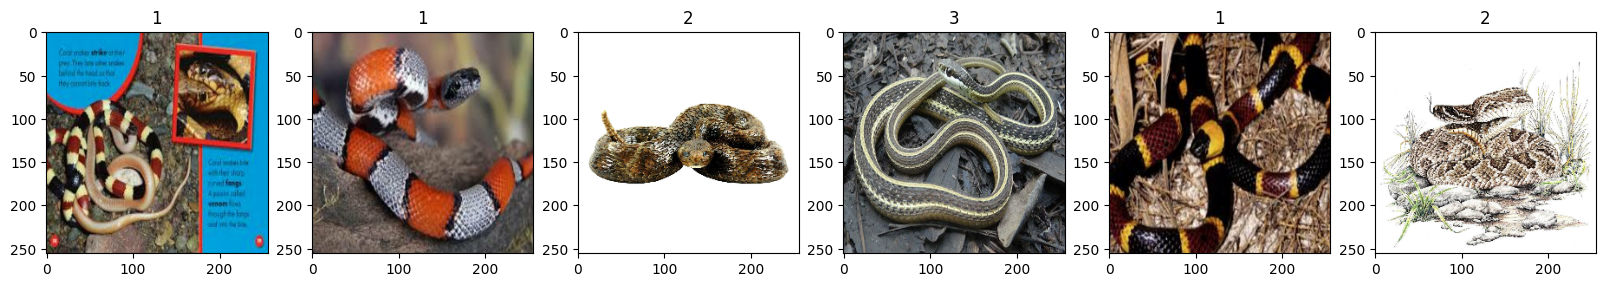

In [15]:
fig, ax = plt.subplots(ncols = 6, figsize = (20,20))
for idx, img in enumerate(batch[0][0:6]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

### Pre-process data

In [16]:
resize_fn = keras.layers.Resizing(150, 150)

#data = data.map(lambda x, y: (x/127.5 - 1, y))
data = data.map(lambda x, y: (resize_fn(x), y))

In [17]:
len(data) # How many batches

38

In [20]:
# NEED TO ADJUST
train_size = int(len(data)*0.7) 
val_size = int(len(data)*0.2) + 1
test_size = int(len(data)*0.1) + 1

In [21]:
train_size, val_size, test_size

(26, 8, 4)

In [22]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [23]:
test.cardinality()

<tf.Tensor: shape=(), dtype=int64, numpy=4>

### Models

In [24]:
logdir='logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [25]:
import efficientnet

In [26]:
IMG_SHAPE = (150, 150, 3)
base_model = keras.applications.EfficientNetB0(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False

i = keras.Input(shape=IMG_SHAPE)
x = base_model(i, training = False)
base_model_layer = keras.Model(inputs = i, outputs = x)

model4 = models.Sequential([
    # augmentation layers
    layers.RandomFlip("horizontal", input_shape=IMG_SHAPE),
    layers.RandomFlip("vertical", input_shape=IMG_SHAPE),
    
    base_model_layer,
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax'),  # outputs the final classification
])

In [27]:
# Compile the model
model4.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Assuming you have train_ds and validation datasets
history_model4 = model4.fit(train,
                            epochs=20,
                            validation_data=val)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6650 - loss: 1.0523 - val_accuracy: 0.9629 - val_loss: 0.1220
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9384 - loss: 0.1884 - val_accuracy: 0.9746 - val_loss: 0.0946
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9497 - loss: 0.1442 - val_accuracy: 0.9707 - val_loss: 0.0944
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9709 - loss: 0.1076 - val_accuracy: 0.9785 - val_loss: 0.0728
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9736 - loss: 0.0766 - val_accuracy: 0.9805 - val_loss: 0.0567
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9809 - loss: 0.0592 - val_accuracy: 0.9766 - val_loss: 0.0697
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9720 - loss: 0.0917 - val_accuracy: 0.9863 - val_loss: 0.0618
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9862 - loss: 0.0527 - val_accuracy: 0.9824 - val_loss:

### Test/Evaluate

Baseline accuracy: $27.37\%$ for 6 classes

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy
pre = Precision()
re = Recall()
acc = CategoricalAccuracy()
for batch in test.as_numpy_iterator(): 
    X, y = batch
    yhat = model4.predict(X)
    yhat = np.where(yhat == max(yhat))
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

print(pre.result(), re.result(), acc.result())

In [28]:
test_loss, test_accuracy = model4.evaluate(test)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 810ms/step - accuracy: 0.9864 - loss: 0.0622
Test Accuracy: 98.43%


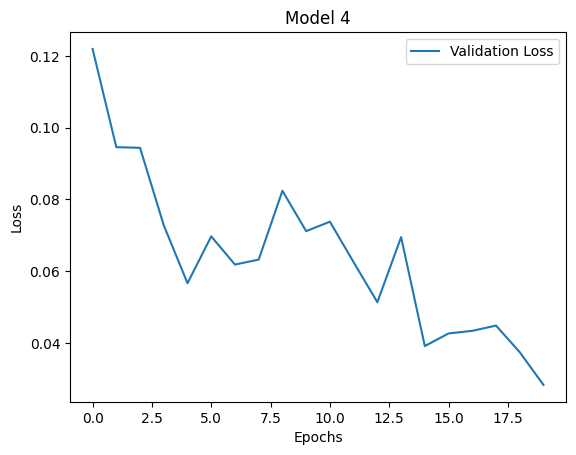

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [29]:
plt.plot(history_model4.history['val_loss'], label='Validation Loss')
#plt.plot(history_model3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model 4')
plt.legend()
plt.show()
print(history_model4.history.keys())